# RNN Text Classification

- This notebook presents an end-to-end deep learning workflow for text classification using recurrent neural networks.

- Two models are implemented and compared: **Simple RNN** and **LSTM**(Long Short-Term Memory).

- Model performance is evaluated using accuracy and a confusion matrix.

**Key concepts covered:**
- Tokenization and sequence encoding  
- Word embeddings as trainable parameters  
- Simple RNN and LSTM architectures  
- Model evaluation

**Steps**:
1. Import libraries and configs
2. Load data and preprocess it with stopwords
3. Define hyperparameters
4. initialize a tokenizer and fit into the articles data
5. Convert the features into sequences
6. Pad the sequences
7. Repeat the same for label data
8. Split the data for train and test
9. Build and train the model
10. model evaluation

In [4]:
import csv
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

#for tokenization
from tensorflow.keras.preprocessing.text import Tokenizer
#for pading sequences
from tensorflow.keras.preprocessing.sequence import pad_sequences

#model components
from tensorflow.keras.layers import Embedding, Bidirectional, Dense, SimpleRNN, Dropout, LSTM
from tensorflow.keras import Sequential

#for splitting the data
from sklearn.model_selection import train_test_split



In [5]:
import nltk # Natural Language Toolkit, Text preprocessing: tokenization, stop words removal, etc...
nltk.download('stopwords')
from nltk.corpus import stopwords
STOPWORDS = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Step 2
1. Read the data form the csv file (articles from BBC website)
2. Split the data into articles (features) and labels (target) lists
3. Remove StopWords

In [6]:
# build empty lists
articles, labels = list(), list()

data_file = '/content/bbc-text.csv'

#loop to read the file
with open(data_file, 'r') as bbc_file:
  reader = csv.reader(bbc_file)
  #skip the first row (header)
  next(reader)

  #iterate for each row
  for row in reader:
    labels.append(row[0])

    #for articles
    article = row[1]

    #loop through to remove stopwords
    for word in STOPWORDS:
      token = ' ' + word + ' '
      article = article.replace(token, ' ')

    articles.append(article)


#### Data Validation

In [7]:
len(articles) == len(labels)

True

In [8]:
labels[:9]

['tech',
 'business',
 'sport',
 'sport',
 'entertainment',
 'politics',
 'politics',
 'sport',
 'sport']

In [9]:
print(f'We have {len(set(labels))} classes. List of unique classes: {set(labels)}')

We have 5 classes. List of unique classes: {'tech', 'sport', 'business', 'politics', 'entertainment'}


In [10]:
articles[:3]

['tv future hands viewers home theatre systems  plasma high-definition tvs  digital video recorders moving living room  way people watch tv radically different five years  time.  according expert panel gathered annual consumer electronics show las vegas discuss new technologies impact one favourite pastimes. us leading trend  programmes content delivered viewers via home networks  cable  satellite  telecoms companies  broadband service providers front rooms portable devices.  one talked-about technologies ces digital personal video recorders (dvr pvr). set-top boxes  like us tivo uk sky+ system  allow people record  store  play  pause forward wind tv programmes want.  essentially  technology allows much personalised tv. also built-in high-definition tv sets  big business japan us  slower take europe lack high-definition programming. people forward wind adverts  also forget abiding network channel schedules  putting together a-la-carte entertainment. us networks cable satellite companie

In [11]:
'is' in articles

False

In [12]:
len(articles[9]), len(articles[120])

(891, 729)

## Natural Language Processing (NLP)

### Basic NLP Concepts

- **Tokenization**: Splitting text into tokens (words or sentences).  
- **Text Cleaning**: Removing punctuation, extra spaces, and stop words.  
- **Text Normalization**: Lowercasing, removing very short/rare words, and stemming or lemmatization.

### Tokenization & Sequence Settings

- **Vocabulary Size**: Limits the number of words kept (e.g., top 5,000 by frequency) to reduce complexity and overfitting.  
- **OOV Token**: Words outside the vocabulary are replaced with a placeholder (e.g., `<OOV>`).  
- **Sequence Length (`maxlen`)**: Sets maximum sequence size; longer sequences are truncated.  
- **Padding & Truncation**: Choose `pre` or `post` to control where padding or truncation happens.


Example:
```
"Hello, World!"
"Hello, World! It's the machine."

"Hello, World! <pad> <pad> <pad>"
```

In [13]:
# for the tokenizer
vocab_size = 5000
oov_tok = '<OOV>'

# for pad sequence
max_length = 200
trunc_type = 'post'
padding_type = 'post'

#for model
embedding_dim = 64 #start with this value, increase it if you get lower performance, decrease if you get overfitting
num_epochs = 7

Step 4 - Tokenization

In [14]:
tokenizer = Tokenizer(num_words=vocab_size, lower=True, oov_token=oov_tok)

We'll fit the tokenizer on the data:
1. Buld the **word index** by analyzing the articles
2. Create a mapping of words to integers based on the word frequency in the data

In [15]:
tokenizer.fit_on_texts(articles)

Next: check the word index

In [16]:
model_word_index=tokenizer.word_index
model_word_index

{'<OOV>': 1,
 'said': 2,
 'mr': 3,
 'would': 4,
 'year': 5,
 'also': 6,
 'people': 7,
 'new': 8,
 'us': 9,
 'one': 10,
 'could': 11,
 'last': 12,
 'first': 13,
 'time': 14,
 'two': 15,
 'world': 16,
 'government': 17,
 'uk': 18,
 'years': 19,
 'best': 20,
 'make': 21,
 'told': 22,
 'get': 23,
 'film': 24,
 'like': 25,
 'game': 26,
 'made': 27,
 'back': 28,
 'music': 29,
 'many': 30,
 'three': 31,
 '000': 32,
 'labour': 33,
 'next': 34,
 '1': 35,
 'bbc': 36,
 'well': 37,
 'set': 38,
 'number': 39,
 'take': 40,
 'way': 41,
 'added': 42,
 'market': 43,
 '2': 44,
 'may': 45,
 'says': 46,
 'company': 47,
 'home': 48,
 'election': 49,
 'good': 50,
 '2004': 51,
 'going': 52,
 'party': 53,
 'still': 54,
 'games': 55,
 'much': 56,
 'england': 57,
 'win': 58,
 '6': 59,
 'go': 60,
 'work': 61,
 'since': 62,
 'firm': 63,
 'second': 64,
 'show': 65,
 'top': 66,
 'blair': 67,
 'think': 68,
 'week': 69,
 'use': 70,
 'say': 71,
 'million': 72,
 'part': 73,
 'play': 74,
 'technology': 75,
 'minister': 

Step 5
- Use `text_to_sequence` to convert the data into a list of integer sequences
- Each word in the article/text is replaced by its corresponding integer

In [17]:
X = tokenizer.texts_to_sequences(articles)
X[:3]

[[88,
  165,
  1143,
  1205,
  48,
  1108,
  726,
  1,
  77,
  1060,
  4253,
  137,
  173,
  4114,
  1331,
  1297,
  1584,
  41,
  7,
  935,
  88,
  1,
  316,
  84,
  19,
  14,
  130,
  3114,
  1317,
  2507,
  563,
  406,
  1263,
  65,
  2948,
  3031,
  1743,
  8,
  881,
  739,
  10,
  940,
  1,
  9,
  641,
  1567,
  1039,
  401,
  1986,
  1205,
  763,
  48,
  489,
  1487,
  2100,
  1642,
  125,
  320,
  114,
  2730,
  803,
  1,
  1074,
  595,
  10,
  4399,
  3834,
  881,
  2566,
  137,
  338,
  173,
  4114,
  1,
  1,
  38,
  66,
  3204,
  25,
  9,
  1,
  18,
  1385,
  135,
  441,
  7,
  128,
  1386,
  74,
  4584,
  474,
  1,
  88,
  1039,
  79,
  1,
  75,
  2101,
  56,
  1,
  88,
  6,
  1109,
  612,
  77,
  1060,
  88,
  1957,
  138,
  149,
  407,
  9,
  2864,
  40,
  139,
  1206,
  77,
  1060,
  4400,
  7,
  474,
  1,
  3115,
  6,
  2679,
  1,
  399,
  1083,
  1,
  1363,
  602,
  1387,
  2066,
  1,
  740,
  9,
  489,
  1487,
  2100,
  125,
  1905,
  397,
  882,
  2067,
  1608,
  37,


Step 6 - Sequence Padding

In [18]:
X = pad_sequences(X,
                  maxlen=max_length,
                  padding=padding_type,
                  truncating=trunc_type)

In [19]:
X[10]

array([2630,    1,  241, 4790,   24,  684,  574,  241, 4790,    1,    1,
       1783,    1,    1, 2630,   24,  677,    1,    1,  162,  276,    1,
        162,  276,  827,  942,  546, 2251,    1, 1224, 1847,    1, 1873,
          1,    1, 4991,    1,    1,    1,    1,    1,    1,  122, 4791,
          1,    2, 2573, 1468,  356,    1,    1,   52,  306,    1,  356,
       2032, 4121,   42,   24, 3846,    1,    1,    1,    1,  545,    1,
          1,    1,  962,  671, 2511,  309, 4792,    1,  361,   24,    1,
        744, 2291,    1, 4793,  140,   10,    1, 3847,  660, 3396,    1,
         24,    1,  444,  942,  546,    1,   97,   13,  668, 4991,  241,
       4790,    1,  592,    1, 1847, 1028,    1, 4261,  728, 2033,  111,
          1,    1,    1, 2801,   24,    1,  102,  276,    1, 1811, 4596,
        545,  498,    1, 1659, 3621,  784, 1267,    1, 1871,   10,   31,
        684,  317,    1,   66,  568,  677,  315, 1614,   24,  499,    1,
          1, 1716,    1,  811,    1, 3213,    1, 12

In [20]:
X.max()

np.int32(4999)

In [21]:
label_tokenizer = Tokenizer()
label_tokenizer.fit_on_texts(labels)
y = np.array(label_tokenizer.texts_to_sequences(labels))

In [22]:
y

array([[4],
       [2],
       [1],
       ...,
       [5],
       [3],
       [1]])

In [23]:
np.unique(y)

array([1, 2, 3, 4, 5])

## **Train / validation / test** split


In [24]:
# Split into train / validation / test
# 1) hold out 20% as a temporary set
# 2) split that temporary set into validation (10%) and test (10%)

# Note: y is shaped (N, 1) because of Tokenizer.texts_to_sequences,
# so we use y.reshape(-1) only for stratification.
y_strat = y.reshape(-1)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=12, stratify=y_strat
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=12, stratify=y_temp.reshape(-1)
)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)


Train: (1780, 200) Val: (222, 200) Test: (223, 200)


## Simple RNN Model

1. Embedding Layer: It's required for every NLP application. It converts the integer-coded words into dense vectors.
2. Bidirectional RNN layer
3. Fully Connected Layer
4. Output Layer

In [25]:
simple_rnn_model = Sequential([
    Embedding(vocab_size, embedding_dim),
    Bidirectional(SimpleRNN(embedding_dim)),
    Dense(embedding_dim, activation='relu'),
    #output layer
    Dense(len(set(labels))+1, activation='softmax') #adding 1 as a best practice for "unknown" category
])

In [26]:
simple_rnn_model.compile(loss='sparse_categorical_crossentropy',
                         optimizer='adam',
                         metrics=['accuracy'])

In [27]:
simple_rnn_model_hist = simple_rnn_model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=num_epochs)

Epoch 1/7
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 86ms/step - accuracy: 0.2392 - loss: 1.6679 - val_accuracy: 0.2838 - val_loss: 1.5408
Epoch 2/7
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - accuracy: 0.4930 - loss: 1.3600 - val_accuracy: 0.4685 - val_loss: 1.3369
Epoch 3/7
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - accuracy: 0.9131 - loss: 0.5568 - val_accuracy: 0.5360 - val_loss: 1.2027
Epoch 4/7
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - accuracy: 1.0000 - loss: 0.0590 - val_accuracy: 0.5721 - val_loss: 1.1168
Epoch 5/7
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 99ms/step - accuracy: 1.0000 - loss: 0.0104 - val_accuracy: 0.5991 - val_loss: 1.1465
Epoch 6/7
56/56 ━━━━━━━━━━━━━━━━━━━━ 13s 154ms/step - accuracy: 1.0000 - loss: 0.0044 - val_accuracy: 0.5901 - val_loss: 1.1667
Epoch 7/7
56/56 ━━━━━━━━━━━━━━━━━━━━ 7s 129ms/step - accuracy: 1.0000 - loss: 0.0029 - val_accuracy: 0.5901 - val_loss: 1.1931


In [28]:
plt.style.use('dark_background')

In [29]:
def plot_train_val(history_data):
  fig, (ax1, ax2) = plt.subplots(1,2,figsize=(18,7))

  ax1.plot(history_data.history['accuracy'], label='train accuracy')
  ax1.plot(history_data.history['val_accuracy'], label='validation accuracy')
  ax1.legend()
  ax1.set_title('Model Accuracy')

  ax2.plot(history_data.history['loss'], label='train loss')
  ax2.plot(history_data.history['val_loss'], label='validation loss')
  ax2.legend()
  ax2.set_title('Model Loss')

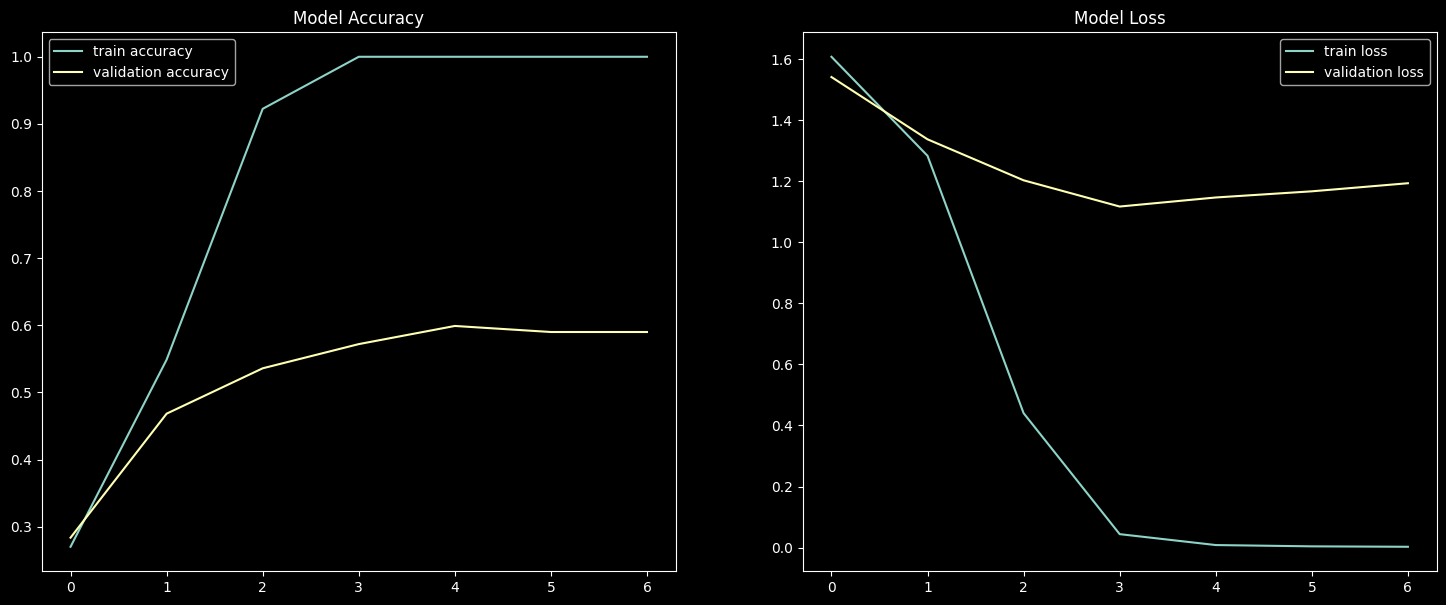

In [30]:
plot_train_val(simple_rnn_model_hist)

## LSTM Model

In [31]:
lstm_rnn_model = Sequential([
    Embedding(vocab_size, embedding_dim),
    Bidirectional(LSTM(embedding_dim)),
    Dense(embedding_dim, activation='relu'),

    #output layer
    Dense(len(set(labels))+1, activation='softmax') #adding 1 as a best practice for "unknown" category
])

In [32]:
lstm_rnn_model.compile(loss='sparse_categorical_crossentropy',
                         optimizer='adam',
                         metrics=['accuracy'])

In [33]:
lstm_rnn_model_hist = lstm_rnn_model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=num_epochs)

Epoch 1/7
56/56 ━━━━━━━━━━━━━━━━━━━━ 15s 183ms/step - accuracy: 0.2560 - loss: 1.6717 - val_accuracy: 0.4820 - val_loss: 1.1362
Epoch 2/7
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 169ms/step - accuracy: 0.5611 - loss: 1.0581 - val_accuracy: 0.5721 - val_loss: 0.9535
Epoch 3/7
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 185ms/step - accuracy: 0.7583 - loss: 0.7427 - val_accuracy: 0.8423 - val_loss: 0.4841
Epoch 4/7
56/56 ━━━━━━━━━━━━━━━━━━━━ 20s 182ms/step - accuracy: 0.9288 - loss: 0.2453 - val_accuracy: 0.9054 - val_loss: 0.2443
Epoch 5/7
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 181ms/step - accuracy: 0.9566 - loss: 0.1398 - val_accuracy: 0.9324 - val_loss: 0.1947
Epoch 6/7
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 163ms/step - accuracy: 0.9663 - loss: 0.1110 - val_accuracy: 0.9459 - val_loss: 0.2494
Epoch 7/7
56/56 ━━━━━━━━━━━━━━━━━━━━ 11s 177ms/step - accuracy: 0.9939 - loss: 0.0350 - val_accuracy: 0.9459 - val_loss: 0.2463


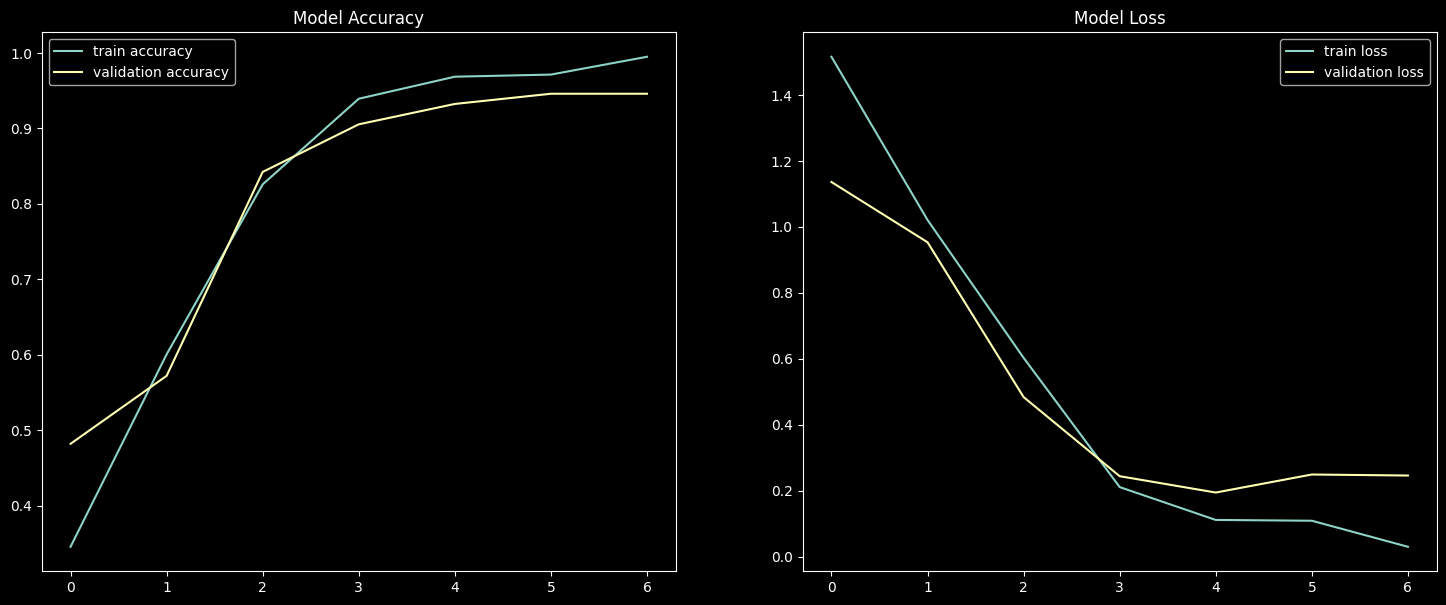

In [34]:
plot_train_val(lstm_rnn_model_hist)

## Evaluation on the **test set**

We only use the test set once, after training is done, to get an unbiased estimate of performance.

In [35]:
from sklearn.metrics import classification_report, confusion_matrix

def evaluate_on_test(model, X_test, y_test, label_tokenizer, title="Model"):
    # Keras returns probabilities over classes
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"\n{title} - Test loss: {test_loss:.4f} | Test accuracy: {test_acc:.4f}")

    # Predicted class indices
    y_pred = model.predict(X_test, verbose=0).argmax(axis=1)

    # True class indices (flatten in case shape is (N,1))
    y_true = y_test.reshape(-1)

    # Build an index -> label mapping
    # Note: Tokenizer assigns indices starting from 1
    idx_to_label = {idx: label for label, idx in label_tokenizer.word_index.items()}
    # Optional: reserve 0 for padding/unknown
    idx_to_label[0] = "PAD/UNK"

    target_names = [idx_to_label[i] for i in sorted(set(y_true))]

    print(classification_report(
        y_true, y_pred,
        labels=sorted(set(y_true)),
        target_names=target_names,
        zero_division=0
    ))

# Evaluate both models
evaluate_on_test(simple_rnn_model, X_test, y_test, label_tokenizer, title="SimpleRNN")
evaluate_on_test(lstm_rnn_model, X_test, y_test, label_tokenizer, title="BiLSTM")



SimpleRNN - Test loss: 1.1083 | Test accuracy: 0.6278
               precision    recall  f1-score   support

        sport       0.59      0.69      0.64        51
     business       0.69      0.47      0.56        51
     politics       0.56      0.64      0.60        42
         tech       0.65      0.60      0.62        40
entertainment       0.68      0.77      0.72        39

     accuracy                           0.63       223
    macro avg       0.63      0.63      0.63       223
 weighted avg       0.63      0.63      0.62       223


BiLSTM - Test loss: 0.1696 | Test accuracy: 0.9417
               precision    recall  f1-score   support

        sport       0.96      1.00      0.98        51
     business       0.98      0.88      0.93        51
     politics       1.00      0.95      0.98        42
         tech       0.80      0.97      0.88        40
entertainment       1.00      0.90      0.95        39

     accuracy                           0.94       223
    macr

Observation:
The BiLSTM dramatically outperforms the Simple RNN. This shows that LSTM’s memory mechanism captures long-range word dependencies much better than a basic RNN.

### Confusion Matrix

In [36]:
y_pred_rnn = simple_rnn_model.predict(X_test)
y_pred_lstm = lstm_rnn_model.predict(X_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step


In [37]:
#convert prob to classes
y_pred_rnn_labels = np.argmax(y_pred_rnn, axis=1)
y_pred_lstm_labels = np.argmax(y_pred_lstm, axis=1)

In [38]:
y_pred_lstm_labels

array([5, 1, 5, 2, 3, 3, 5, 3, 2, 5, 2, 4, 2, 4, 4, 1, 1, 5, 4, 3, 4, 1,
       3, 4, 2, 3, 4, 1, 1, 1, 3, 3, 2, 5, 5, 5, 2, 2, 4, 2, 4, 3, 3, 3,
       3, 4, 3, 1, 4, 4, 1, 1, 4, 1, 2, 4, 2, 3, 2, 3, 4, 3, 5, 3, 1, 5,
       5, 1, 4, 2, 4, 4, 3, 2, 1, 3, 5, 3, 1, 5, 1, 4, 4, 2, 1, 2, 4, 1,
       2, 4, 2, 2, 3, 5, 1, 1, 1, 4, 1, 3, 2, 3, 4, 1, 1, 2, 4, 3, 3, 3,
       5, 4, 4, 5, 5, 3, 2, 4, 1, 2, 1, 1, 1, 2, 1, 4, 5, 2, 4, 1, 5, 1,
       2, 3, 5, 5, 5, 1, 2, 3, 1, 3, 2, 5, 1, 5, 4, 2, 2, 1, 4, 2, 1, 1,
       3, 1, 2, 1, 4, 5, 1, 5, 5, 1, 2, 2, 4, 5, 2, 2, 1, 3, 3, 3, 1, 2,
       5, 5, 5, 2, 4, 3, 4, 4, 3, 1, 1, 1, 2, 4, 2, 1, 2, 4, 5, 4, 2, 4,
       4, 2, 1, 2, 4, 1, 1, 5, 5, 1, 4, 4, 2, 5, 4, 1, 4, 4, 3, 3, 3, 2,
       4, 3, 1])

In [39]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [40]:
label_list = label_tokenizer.word_index.keys()
list(label_list)

['sport', 'business', 'politics', 'tech', 'entertainment']

[Text(0, 0, 'sport'),
 Text(0, 1, 'business'),
 Text(0, 2, 'politics'),
 Text(0, 3, 'tech'),
 Text(0, 4, 'entertainment')]

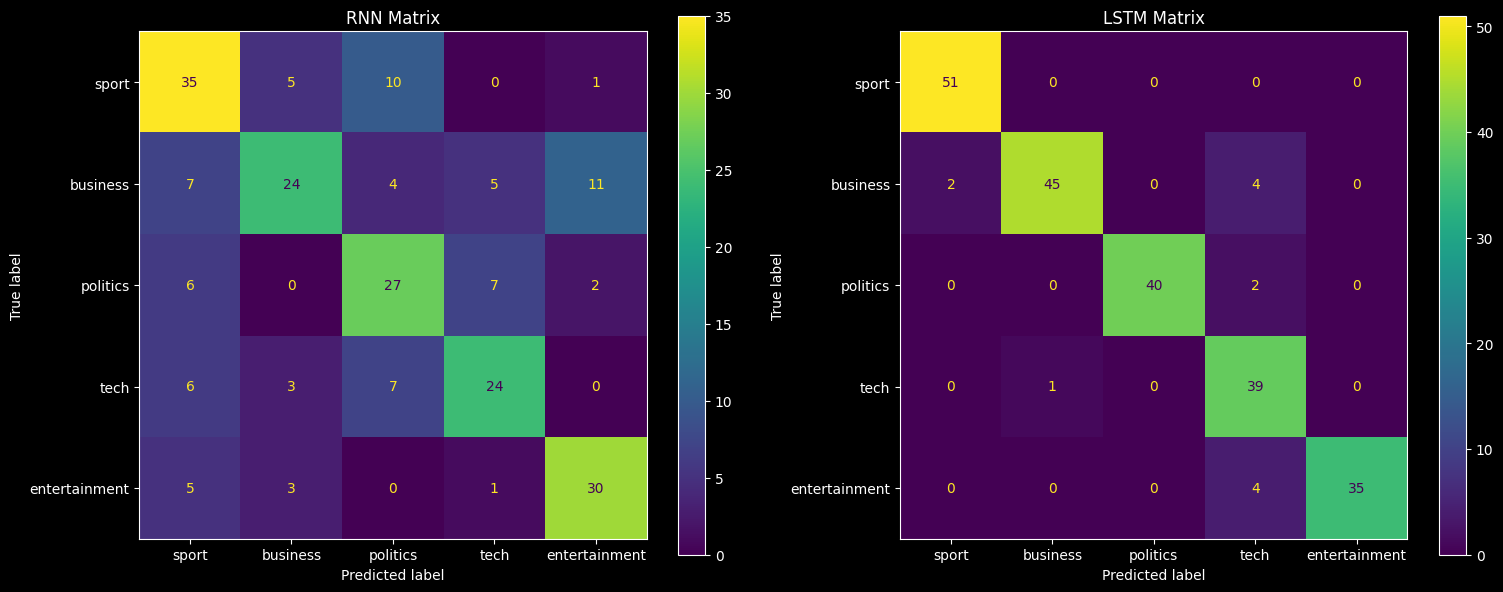

In [41]:
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(18,7))

cm_rnn = confusion_matrix(y_test, y_pred_rnn_labels)
disp_rnn = ConfusionMatrixDisplay(confusion_matrix=cm_rnn)
disp_rnn.plot(ax=ax1)
ax1.set_title('RNN Matrix')
ax1.set_xticklabels(list(label_list))
ax1.set_yticklabels(list(label_list))

cm_lstm = confusion_matrix(y_test, y_pred_lstm_labels)
disp_lstm = ConfusionMatrixDisplay(confusion_matrix=cm_lstm)
disp_lstm.plot(ax=ax2)
ax2.set_title('LSTM Matrix')
ax2.set_xticklabels(list(label_list))
ax2.set_yticklabels(list(label_list))


Observations:
- Simple RNN shows many  misclassification.

- BiLSTM is highly diagonal, most predictions are correct.